# BikeWale Bike Market Analysis Using Web Scraping, Regex & Data Analytics

**Project:** End-to-End Regex & Web Scraping Project  
**Website:** BikeWale  
**Assigned problem statement:** Analysis on fnding out the best bikes in India based on their feautures.

## Project objective
Extract meaningful bike data from BikeWale, transform raw web data into a structured dataset, clean and analyze it, create visualizations, and generate business insights and recommendations.

# PART 1 — WEBSITE SELECTION

### Selected website
**BikeWale**

Main website: https://www.bikewale.com/  
Data collection page: https://www.bikewale.com/new-bike-search/

### Why BikeWale?
- It contains multiple bike features useful for comparison.
- The data supports an end-to-end web scraping and analytics workflow.
- It directly matches the assigned problem statement.

### Project question
**Which bikes perform best in our scraped BikeWale dataset when we compare ratings, mileage, power and price?**

# PART 2 — DATA COLLECTION / WEB SCRAPING

We use:
- `requests` for the HTTP request
- `BeautifulSoup` for HTML parsing
- `Regex` for extracting values from text
- `Pandas` for structuring the records

In [1]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://www.bikewale.com/new-bike-search/"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/140.0.0.0 Safari/537.36"
    )
}

response = requests.get(url, headers=headers, timeout=20)

print("Status Code:", response.status_code)
print("Final URL:", response.url)
print("Page Length:", len(response.text))

if response.status_code != 200:
    raise RuntimeError("BikeWale did not return a successful response.")

Status Code: 200
Final URL: https://www.bikewale.com/new-bike-search/
Page Length: 470388


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print("HTML parsed successfully!")
print("Page title:", soup.title.get_text(" ", strip=True) if soup.title else "No title found")

HTML parsed successfully!
Page title: Search New Bikes by Brand, Budget, Mileage and Ride Style - BikeWale


## Regex extraction

Regex patterns are used to extract:
- Rating: `x/5`
- Ratings count: `number Ratings`
- Engine: `number cc`
- Mileage: `number kmpl`
- Power: `number bhp`
- Weight: `number kg`
- Price: `₹ number`

Some electric bikes do not use the conventional petrol-bike specification format. Those unavailable fields are kept as `NaN`, not zero.

In [4]:
bike_cards = soup.find_all("div", class_="o-f7")
print("Possible bike cards found:", len(bike_cards))

Possible bike cards found: 32


In [5]:
bike_data = []

for card in bike_cards:
    name_element = card.find("h3")
    if not name_element:
        continue

    name = name_element.get_text(" ", strip=True)
    text = card.get_text(" ", strip=True)

    rating_match = re.search(r"(\d+(?:\.\d+)?)\s*/5", text)
    ratings_match = re.search(r"([\d,]+)\s+Ratings", text)
    engine_match = re.search(r"([\d.]+)\s*cc", text)
    mileage_match = re.search(r"([\d.]+)\s*kmpl", text)
    power_match = re.search(r"([\d.]+)\s*bhp", text)
    weight_match = re.search(r"([\d.]+)\s*kg", text)
    price_match = re.search(r"₹\s*([\d,]+)", text)

    bike_data.append({
        "Bike Name": name,
        "Rating": float(rating_match.group(1)) if rating_match else np.nan,
        "Ratings Count": int(ratings_match.group(1).replace(",", "")) if ratings_match else np.nan,
        "Engine CC": float(engine_match.group(1)) if engine_match else np.nan,
        "Mileage (kmpl)": float(mileage_match.group(1)) if mileage_match else np.nan,
        "Power (bhp)": float(power_match.group(1)) if power_match else np.nan,
        "Weight (kg)": float(weight_match.group(1)) if weight_match else np.nan,
        "Price (₹)": int(price_match.group(1).replace(",", "")) if price_match else np.nan
    })

print("Raw records extracted:", len(bike_data))

if len(bike_data) == 0:
    raise RuntimeError("No bike records were extracted. The website HTML structure may have changed.")

Raw records extracted: 30


### Data collection observation

> **Observation:** The scraping process collects bike records from the BikeWale new-bike listing page. Requests and BeautifulSoup are used for collection and parsing, while Regex extracts specific values such as rating, mileage, power, weight and price from the bike-card text.

# PART 3 — DATA STRUCTURING

The extracted records are converted into a Pandas DataFrame for analysis.

In [6]:
df = pd.DataFrame(bike_data)

print("Dataset shape:", df.shape)
display(df.head(10))

Dataset shape: (30, 8)


,Bike Name,Rating,Ratings Count,Engine CC,Mileage (kmpl),Power (bhp),Weight (kg),Price (₹)
0,TVS Raider 125,4.4,2958.0,124.80,56.7,11.20,123.0,86397
1,Bajaj Pulsar N160 2V,4.6,1279.0,164.82,51.6,15.68,152.0,122990
2,TVS Apache RTR 160,4.5,3351.0,159.70,61.0,15.82,138.0,110781
3,Honda SP 125,4.6,4551.0,123.94,63.0,10.72,117.0,90636
4,Royal Enfield Hunter 350,4.7,1796.0,349.34,36.2,20.20,181.0,137640
5,Royal Enfield Classic 350,4.6,50.0,349.00,34.0,20.20,195.0,187434
6,Royal Enfield Bullet 350,4.7,1577.0,349.00,35.0,20.20,195.0,165656
7,TVS Ronin,2.5,1.0,225.90,42.0,20.10,160.0,130290
8,Royal Enfield Himalayan 440,4.6,29.0,443.00,31.0,25.40,199.0,229000
9,TVS iQube,3.7,882.0,NaN,NaN,NaN,129.7,119565


In [7]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(i, "-", column)

Columns:
1 - Bike Name
2 - Rating
3 - Ratings Count
4 - Engine CC
5 - Mileage (kmpl)
6 - Power (bhp)
7 - Weight (kg)
8 - Price (₹)


# PART 4 — DATA UNDERSTANDING

We inspect the dataset shape, data types, missing values, duplicates and summary statistics.

In [8]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset shape: (30, 8)

Data types:
Bike Name          object
Rating            float64
Ratings Count     float64
Engine CC         float64
Mileage (kmpl)    float64
Power (bhp)       float64
Weight (kg)       float64
Price (₹)           int64
dtype: object


In [9]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Bike Name         0
Rating            1
Ratings Count     1
Engine CC         2
Mileage (kmpl)    2
Power (bhp)       2
Weight (kg)       0
Price (₹)         0
dtype: int64


In [10]:
print("Duplicate full rows:", df.duplicated().sum())
print("Duplicate bike names:", df["Bike Name"].duplicated().sum())

Duplicate full rows: 0
Duplicate bike names: 0


In [11]:
print("Summary statistics:")
display(df.describe().T)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Rating,29.0,4.479310,0.439463,2.50,4.500,4.60,4.7000,4.8
Ratings Count,29.0,1388.344828,1505.436298,1.00,71.000,937.00,1902.0000,4857.0
Engine CC,28.0,252.660357,141.948380,97.20,124.800,182.16,349.0325,648.0
Mileage (kmpl),28.0,42.615714,12.249068,22.00,32.000,41.70,50.4000,66.0
Power (bhp),28.0,20.457857,10.690205,7.88,11.350,19.10,24.4475,47.0
Weight (kg),30.0,154.156667,33.155201,105.00,129.175,149.00,184.7500,211.0
Price (₹),30.0,154929.433333,69640.773303,77124.00,94655.500,138459.50,195608.2500,358427.0


In [12]:
numeric_columns = [
    "Rating", "Ratings Count", "Engine CC",
    "Mileage (kmpl)", "Power (bhp)",
    "Weight (kg)", "Price (₹)"
]

print("Negative values:")
display((df[numeric_columns] < 0).sum())

Negative values:


Rating            0
Ratings Count     0
Engine CC         0
Mileage (kmpl)    0
Power (bhp)       0
Weight (kg)       0
Price (₹)         0
dtype: int64

### Data understanding observation

> **Observation:** The dataset contains the bike records successfully extracted from the selected listing page. Missing values can occur because some electric-bike records do not provide conventional `cc`, `kmpl` or `bhp` fields in the same format. These values are treated as missing rather than zero.

# PART 5 — DATA CLEANING

### Data Cleaning Documentation

1. Remove unnecessary spaces from bike names.
2. Convert numerical columns to numeric data types.
3. Remove duplicate rows.
4. Check for duplicate bike names.
5. Check for negative/impossible numerical values.
6. Preserve unavailable specifications as `NaN`.
7. Keep the raw DataFrame separate from the cleaned DataFrame.

In [13]:
# Create a copy of the original dataset

df_clean = df.copy()

print("Cleaned dataset copy created successfully!")
print("Shape:", df_clean.shape)

Cleaned dataset copy created successfully!
Shape: (30, 8)


In [14]:
# Check missing values

print("Missing values before cleaning:")
print(df_clean.isnull().sum())

Missing values before cleaning:
Bike Name         0
Rating            1
Ratings Count     1
Engine CC         2
Mileage (kmpl)    2
Power (bhp)       2
Weight (kg)       0
Price (₹)         0
dtype: int64


In [15]:
# Data Cleaning - Step 3
# Keep missing values as NaN

print("Missing values are retained as NaN for bikes where these specifications are not available.")

Missing values are retained as NaN for bikes where these specifications are not available.


In [16]:
# Remove unnecessary spaces from bike names

df_clean["Bike Name"] = df_clean["Bike Name"].str.strip()

print("Bike names cleaned successfully!")
print(df_clean["Bike Name"].head())

Bike names cleaned successfully!
0              TVS Raider 125
1        Bajaj Pulsar N160 2V
2          TVS Apache RTR 160
3                Honda SP 125
4    Royal Enfield Hunter 350
Name: Bike Name, dtype: object


In [17]:
# Check for duplicate rows
# Check for duplicate bike names

print("Duplicate rows:", df_clean.duplicated().sum())

print("Duplicate bike names:", df_clean["Bike Name"].duplicated().sum())

Duplicate rows: 0
Duplicate bike names: 0


In [18]:
# Check for zero values

print("Zero values:")
print((df_clean.select_dtypes(include="number") == 0).sum())

Zero values:
Rating            0
Ratings Count     0
Engine CC         0
Mileage (kmpl)    0
Power (bhp)       0
Weight (kg)       0
Price (₹)         0
dtype: int64


In [19]:
# Check for negative values

print("Negative values:")
print((df_clean.select_dtypes(include="number") < 0).sum())

Negative values:
Rating            0
Ratings Count     0
Engine CC         0
Mileage (kmpl)    0
Power (bhp)       0
Weight (kg)       0
Price (₹)         0
dtype: int64


In [20]:
# Check the rating range

print("Rating range:")
print(df_clean["Rating"].min(), "to", df_clean["Rating"].max())

Rating range:
2.5 to 4.8


In [21]:
# Check ratings count range

print("Ratings Count range:")
print(df_clean["Ratings Count"].min(), "to", df_clean["Ratings Count"].max())

Ratings Count range:
1.0 to 4857.0


In [22]:
# Check price range
print("Price range:")
print(df_clean["Price (₹)"].min(), "to", df_clean["Price (₹)"].max())

Price range:
77124 to 358427


In [23]:
# Check mileage range
print("\nMileage range:")
print(df_clean["Mileage (kmpl)"].min(), "to", df_clean["Mileage (kmpl)"].max())



Mileage range:
22.0 to 66.0


In [24]:
# Check power range
print("\nPower range:")
print(df_clean["Power (bhp)"].min(), "to", df_clean["Power (bhp)"].max())


Power range:
7.88 to 47.0


In [25]:
# Check engine CC range
print("\nEngine CC range:")
print(df_clean["Engine CC"].min(), "to", df_clean["Engine CC"].max())


Engine CC range:
97.2 to 648.0


In [26]:
# Check weight range

print("Weight range:")
print(df_clean["Weight (kg)"].min(), "to", df_clean["Weight (kg)"].max())

Weight range:
105.0 to 211.0


In [27]:

# Final missing values check
print("\nFinal missing values:")
print(df_clean.isnull().sum())


Final missing values:
Bike Name         0
Rating            1
Ratings Count     1
Engine CC         2
Mileage (kmpl)    2
Power (bhp)       2
Weight (kg)       0
Price (₹)         0
dtype: int64


In [28]:
# Final dataset shape
print("\nFinal dataset shape:")
print(df_clean.shape)


Final dataset shape:
(30, 8)


In [29]:
# Final verification of cleaned dataset

print("Final cleaned dataset:")
df_clean.head()

Final cleaned dataset:


,Bike Name,Rating,Ratings Count,Engine CC,Mileage (kmpl),Power (bhp),Weight (kg),Price (₹)
0,TVS Raider 125,4.4,2958.0,124.80,56.7,11.20,123.0,86397
1,Bajaj Pulsar N160 2V,4.6,1279.0,164.82,51.6,15.68,152.0,122990
2,TVS Apache RTR 160,4.5,3351.0,159.70,61.0,15.82,138.0,110781
3,Honda SP 125,4.6,4551.0,123.94,63.0,10.72,117.0,90636
4,Royal Enfield Hunter 350,4.7,1796.0,349.34,36.2,20.20,181.0,137640


### Data cleaning observation

> **Observation:** The scraped data was standardized and checked for duplicates and invalid numeric values. Missing conventional specifications were retained as missing values so that the analysis would not introduce false zero values.

In [30]:
# Data Dictionary

data_dictionary = {
    "Column": [
        "Bike Name",
        "Rating",
        "Ratings Count",
        "Engine CC",
        "Mileage (kmpl)",
        "Power (bhp)",
        "Weight (kg)",
        "Price (₹)"
    ],
    
    "Description": [
        "Name of the bike",
        "Customer rating of the bike out of 5",
        "Number of customer ratings",
        "Engine capacity in cubic centimetres",
        "Mileage of the bike in kilometres per litre",
        "Engine power in brake horsepower",
        "Weight of the bike in kilograms",
        "Price of the bike in Indian Rupees"
    ]
}

data_dictionary_df = pd.DataFrame(data_dictionary)

data_dictionary_df

,Column,Description
0,Bike Name,Name of the bike
1,Rating,Customer rating of the bike out of 5
2,Ratings Count,Number of customer ratings
3,Engine CC,Engine capacity in cubic centimetres
4,Mileage (kmpl),Mileage of the bike in kilometres per litre
5,Power (bhp),Engine power in brake horsepower
6,Weight (kg),Weight of the bike in kilograms
7,Price (₹),Price of the bike in Indian Rupees


# PART 6 — EXPLORATORY DATA ANALYSIS (EDA)

In [31]:
# Basic statistics of the cleaned dataset

print("Basic statistics:")
df_clean.describe()

Basic statistics:


,Rating,Ratings Count,Engine CC,Mileage (kmpl),Power (bhp),Weight (kg),Price (₹)
count,29.000000,29.000000,28.000000,28.000000,28.000000,30.000000,30.000000
mean,4.479310,1388.344828,252.660357,42.615714,20.457857,154.156667,154929.433333
std,0.439463,1505.436298,141.948380,12.249068,10.690205,33.155201,69640.773303
min,2.500000,1.000000,97.200000,22.000000,7.880000,105.000000,77124.000000
25%,4.500000,71.000000,124.800000,32.000000,11.350000,129.175000,94655.500000
50%,4.600000,937.000000,182.160000,41.700000,19.100000,149.000000,138459.500000
75%,4.700000,1902.000000,349.032500,50.400000,24.447500,184.750000,195608.250000
max,4.800000,4857.000000,648.000000,66.000000,47.000000,211.000000,358427.000000


In [32]:
# Top 10 bikes by rating

top_rating = df_clean.sort_values(
    by="Rating",
    ascending=False
).head(10)

print("Top 10 bikes by rating:")
top_rating[["Bike Name", "Rating", "Ratings Count"]]

Top 10 bikes by rating:


,Bike Name,Rating,Ratings Count
29,Ather Konarc,4.8,39.0
15,Yamaha R15 V4,4.8,1547.0
26,Bajaj Pulsar NS200,4.7,3346.0
16,Royal Enfield Meteor 350,4.7,250.0
13,Royal Enfield Continental GT 650,4.7,26.0
12,Yamaha MT 15 V2,4.7,1868.0
25,Royal Enfield Himalayan 450,4.7,405.0
6,Royal Enfield Bullet 350,4.7,1577.0
4,Royal Enfield Hunter 350,4.7,1796.0
18,Royal Enfield Guerrilla 450,4.7,71.0


In [33]:
# Top 10 bikes by mileage

top_mileage = df_clean.dropna(
    subset=["Mileage (kmpl)"]
).sort_values(
    by="Mileage (kmpl)",
    ascending=False
).head(10).reset_index(drop=True)

print("Top 10 bikes by mileage:")
top_mileage[["Bike Name", "Mileage (kmpl)", "Price (₹)"]]

Top 10 bikes by mileage:


,Bike Name,Mileage (kmpl),Price (₹)
0,Hero Xtreme 125R,66.00,92841
1,Honda SP 125,63.00,90636
2,Hero Splendor Plus,63.00,77124
3,TVS Apache RTR 160,61.00,110781
4,TVS Raider 125,56.70,86397
5,TVS Jupiter,53.84,77352
6,Bajaj Pulsar N160 2V,51.60,122990
7,TVS Jupiter 125,50.00,87469
8,TVS Ntorq 125,48.50,90558
9,Honda Activa,47.00,78687


In [34]:
# Top 10 most affordable bikes

top_affordable = df_clean.sort_values(
    by="Price (₹)",
    ascending=True
).head(10).reset_index(drop=True)

print("Top 10 most affordable bikes:")
top_affordable[["Bike Name", "Price (₹)", "Rating"]]

Top 10 most affordable bikes:


,Bike Name,Price (₹),Rating
0,Hero Splendor Plus,77124,4.6
1,TVS Jupiter,77352,4.5
2,Honda Activa,78687,4.4
3,TVS Raider 125,86397,4.4
4,TVS Jupiter 125,87469,4.1
5,TVS Ntorq 125,90558,4.4
6,Honda SP 125,90636,4.6
7,Hero Xtreme 125R,92841,4.6
8,Ather Konarc,100099,4.8
9,TVS Apache RTR 160,110781,4.5


In [35]:
# Price vs Rating

print("Price vs Rating:")
df_clean[["Bike Name", "Price (₹)", "Rating"]].sort_values(
    by="Price (₹)",
    ascending=False
).head(10)

Price vs Rating:


,Bike Name,Price (₹),Rating
13,Royal Enfield Continental GT 650,358427,4.7
25,Royal Enfield Himalayan 450,308029,4.7
18,Royal Enfield Guerrilla 450,251063,4.7
8,Royal Enfield Himalayan 440,229000,4.6
11,Jawa All Stars 42 Bobber,210981,4.4
14,Yezdi Roadster,201940,4.5
16,Royal Enfield Meteor 350,199447,4.7
28,Honda CB350RS,198333,4.6
5,Royal Enfield Classic 350,187434,4.6
20,Bajaj Pulsar NS400Z,186150,4.5


In [36]:
# EDA - Most reviewed bikes

most_reviewed_bikes = df_clean.sort_values(
    by="Ratings Count",
    ascending=False
)[["Bike Name", "Rating", "Ratings Count"]]

print("Bikes with the highest number of ratings:")
print(most_reviewed_bikes.head(10).to_string(index=False))

Bikes with the highest number of ratings:
               Bike Name  Rating  Ratings Count
      Hero Splendor Plus     4.6         4857.0
            Honda SP 125     4.6         4551.0
            Honda Activa     4.4         4277.0
      TVS Apache RTR 160     4.5         3351.0
      Bajaj Pulsar NS200     4.7         3346.0
          TVS Raider 125     4.4         2958.0
           TVS Ntorq 125     4.4         2302.0
        Hero Xtreme 125R     4.6         1902.0
         Yamaha MT 15 V2     4.7         1868.0
Royal Enfield Hunter 350     4.7         1796.0


In [37]:
# EDA - Bikes with the highest power

highest_power_bikes = df_clean.dropna(
    subset=["Power (bhp)"]
).sort_values(
    by="Power (bhp)",
    ascending=False
)[["Bike Name", "Power (bhp)", "Engine CC", "Price (₹)", "Rating"]]

print("Bikes with the highest power:")
print(highest_power_bikes.head(10).to_string(index=False))

Bikes with the highest power:
                       Bike Name  Power (bhp)  Engine CC  Price (₹)  Rating
Royal Enfield Continental GT 650        47.00     648.00     358427     4.7
             Bajaj Pulsar NS400Z        40.04     349.13     186150     4.5
     Royal Enfield Himalayan 450        39.47     451.65     308029     4.7
     Royal Enfield Guerrilla 450        39.47     452.00     251063     4.7
        Jawa All Stars 42 Bobber        29.51     334.00     210981     4.4
                  Yezdi Roadster        28.70     334.00     201940     4.5
     Royal Enfield Himalayan 440        25.40     443.00     229000     4.6
              Bajaj Pulsar NS200        24.13     199.50     139279     4.7
                   Honda CB350RS        20.78     348.36     198333     4.6
        Royal Enfield Meteor 350        20.20     349.34     199447     4.7


In [38]:
# EDA - Heaviest bikes

heaviest_bikes = df_clean.sort_values(
    by="Weight (kg)",
    ascending=False
)[["Bike Name", "Weight (kg)", "Engine CC", "Power (bhp)", "Price (₹)"]]

print("Heaviest bikes:")
print(heaviest_bikes.head(10).to_string(index=False))

Heaviest bikes:
                       Bike Name  Weight (kg)  Engine CC  Power (bhp)  Price (₹)
Royal Enfield Continental GT 650        211.0     648.00        47.00     358427
     Royal Enfield Himalayan 440        199.0     443.00        25.40     229000
     Royal Enfield Himalayan 450        195.0     451.65        39.47     308029
       Royal Enfield Classic 350        195.0     349.00        20.20     187434
        Royal Enfield Bullet 350        195.0     349.00        20.20     165656
        Royal Enfield Meteor 350        191.0     349.34        20.20     199447
     Royal Enfield Guerrilla 450        185.0     452.00        39.47     251063
        Jawa All Stars 42 Bobber        185.0     334.00        29.51     210981
                  Yezdi Roadster        184.0     334.00        28.70     201940
        Royal Enfield Hunter 350        181.0     349.34        20.20     137640


In [39]:
# EDA - Bikes with the lowest power

lowest_power_bikes = df_clean.dropna(
    subset=["Power (bhp)"]
).sort_values(
    by="Power (bhp)",
    ascending=True
)[["Bike Name", "Power (bhp)", "Engine CC", "Mileage (kmpl)", "Price (₹)", "Rating"]]

print("Bikes with the lowest power:")
print(lowest_power_bikes.head(10).to_string(index=False))

Bikes with the lowest power:
           Bike Name  Power (bhp)  Engine CC  Mileage (kmpl)  Price (₹)  Rating
        Honda Activa         7.88     109.51           47.00      78687     4.4
         TVS Jupiter         7.91     113.30           53.84      77352     4.5
  Hero Splendor Plus         7.91      97.20           63.00      77124     4.6
     TVS Jupiter 125         8.04     124.80           50.00      87469     4.1
       TVS Ntorq 125         9.25     124.80           48.50      90558     4.4
        Honda SP 125        10.72     123.94           63.00      90636     4.6
      TVS Raider 125        11.20     124.80           56.70      86397     4.4
    Hero Xtreme 125R        11.40     124.70           66.00      92841     4.6
Bajaj Pulsar N160 2V        15.68     164.82           51.60     122990     4.6
  TVS Apache RTR 160        15.82     159.70           61.00     110781     4.5


In [40]:
# EDA - Potential value-for-money bikes

value_bikes = df_clean.dropna(
    subset=["Mileage (kmpl)"]
).copy()

value_bikes["Value Score"] = (
    value_bikes["Rating"] *
    value_bikes["Mileage (kmpl)"]
) / value_bikes["Price (₹)"] * 100000

value_bikes = value_bikes.sort_values(
    by="Value Score",
    ascending=False
)[[
    "Bike Name",
    "Price (₹)",
    "Rating",
    "Mileage (kmpl)",
    "Value Score"
]]

print("Potential value-for-money bikes:")
print(value_bikes.head(10).to_string(index=False))

Potential value-for-money bikes:
           Bike Name  Price (₹)  Rating  Mileage (kmpl)  Value Score
  Hero Splendor Plus      77124     4.6           63.00   375.758519
    Hero Xtreme 125R      92841     4.6           66.00   327.010696
        Honda SP 125      90636     4.6           63.00   319.740500
         TVS Jupiter      77352     4.5           53.84   313.217499
      TVS Raider 125      86397     4.4           56.70   288.760026
        Honda Activa      78687     4.4           47.00   262.813425
  TVS Apache RTR 160     110781     4.5           61.00   247.786173
       TVS Ntorq 125      90558     4.4           48.50   235.650081
     TVS Jupiter 125      87469     4.1           50.00   234.368748
Bajaj Pulsar N160 2V     122990     4.6           51.60   192.991300


In [41]:
# EDA - Engine capacity vs power

engine_power = df_clean.dropna(
    subset=["Engine CC", "Power (bhp)"]
)[[
    "Bike Name",
    "Engine CC",
    "Power (bhp)",
    "Price (₹)"
]].sort_values(
    by="Engine CC",
    ascending=False
)

print("Engine capacity vs power:")
print(engine_power.to_string(index=False))

Engine capacity vs power:
                       Bike Name  Engine CC  Power (bhp)  Price (₹)
Royal Enfield Continental GT 650     648.00        47.00     358427
     Royal Enfield Guerrilla 450     452.00        39.47     251063
     Royal Enfield Himalayan 450     451.65        39.47     308029
     Royal Enfield Himalayan 440     443.00        25.40     229000
        Royal Enfield Meteor 350     349.34        20.20     199447
        Royal Enfield Hunter 350     349.34        20.20     137640
             Bajaj Pulsar NS400Z     349.13        40.04     186150
       Royal Enfield Classic 350     349.00        20.20     187434
        Royal Enfield Bullet 350     349.00        20.20     165656
                   Honda CB350RS     348.36        20.78     198333
        Jawa All Stars 42 Bobber     334.00        29.51     210981
                  Yezdi Roadster     334.00        28.70     201940
                       TVS Ronin     225.90        20.10     130290
              Bajaj Pu

In [42]:
# EDA - Popularity Score

popularity_bikes = df_clean.copy()

popularity_bikes["Popularity Score"] = (
    popularity_bikes["Rating"] *
    popularity_bikes["Ratings Count"]
)

popularity_bikes = popularity_bikes.sort_values(
    by="Popularity Score",
    ascending=False
)[[
    "Bike Name",
    "Rating",
    "Ratings Count",
    "Popularity Score"
]]

print("Top 10 bikes by Popularity Score:")
print(popularity_bikes.head(10).to_string(index=False))

Top 10 bikes by Popularity Score:
               Bike Name  Rating  Ratings Count  Popularity Score
      Hero Splendor Plus     4.6         4857.0           22342.2
            Honda SP 125     4.6         4551.0           20934.6
            Honda Activa     4.4         4277.0           18818.8
      Bajaj Pulsar NS200     4.7         3346.0           15726.2
      TVS Apache RTR 160     4.5         3351.0           15079.5
          TVS Raider 125     4.4         2958.0           13015.2
           TVS Ntorq 125     4.4         2302.0           10128.8
         Yamaha MT 15 V2     4.7         1868.0            8779.6
        Hero Xtreme 125R     4.6         1902.0            8749.2
Royal Enfield Hunter 350     4.7         1796.0            8441.2


In [43]:
# EDA - Price per BHP

price_power = df_clean.dropna(
    subset=["Power (bhp)"]
).copy()

price_power["Price per BHP"] = (
    price_power["Price (₹)"] /
    price_power["Power (bhp)"]
)

price_power = price_power.sort_values(
    by="Price per BHP",
    ascending=True
)[[
    "Bike Name",
    "Price (₹)",
    "Power (bhp)",
    "Price per BHP",
    "Rating"
]]

print("Bikes with the lowest Price per BHP:")
print(price_power.head(10).to_string(index=False))

Bikes with the lowest Price per BHP:
                       Bike Name  Price (₹)  Power (bhp)  Price per BHP  Rating
             Bajaj Pulsar NS400Z     186150        40.04    4649.100899     4.5
              Bajaj Pulsar NS200     139279        24.13    5772.026523     4.7
     Royal Enfield Guerrilla 450     251063        39.47    6360.856347     4.7
                       TVS Ronin     130290        20.10    6482.089552     2.5
           TVS Apache RTR 160 4V     116484        17.31    6729.289428     NaN
        Royal Enfield Hunter 350     137640        20.20    6813.861386     4.7
              TVS Apache RTR 160     110781        15.82    7002.591656     4.5
                  Yezdi Roadster     201940        28.70    7036.236934     4.5
        Jawa All Stars 42 Bobber     210981        29.51    7149.474754     4.4
Royal Enfield Continental GT 650     358427        47.00    7626.106383     4.7


In [44]:
# EDA - Correlation between numerical features

corr_columns = [
    "Rating",
    "Ratings Count",
    "Engine CC",
    "Mileage (kmpl)",
    "Power (bhp)",
    "Weight (kg)",
    "Price (₹)"
]

correlation_matrix = df_clean[corr_columns].corr()

print("Correlation matrix:")
display(correlation_matrix.round(2))

Correlation matrix:


,Rating,Ratings Count,Engine CC,Mileage (kmpl),Power (bhp),Weight (kg),Price (₹)
Rating,1.00,0.13,0.17,-0.09,0.14,0.17,0.23
Ratings Count,0.13,1.00,-0.65,0.71,-0.61,-0.62,-0.60
Engine CC,0.17,-0.65,1.00,-0.86,0.88,0.92,0.92
Mileage (kmpl),-0.09,0.71,-0.86,1.00,-0.82,-0.85,-0.83
Power (bhp),0.14,-0.61,0.88,-0.82,1.00,0.81,0.91
Weight (kg),0.17,-0.62,0.92,-0.85,0.81,1.00,0.85
Price (₹),0.23,-0.60,0.92,-0.83,0.91,0.85,1.00


**Observation:** The correlation analysis shows strong positive relationships between Engine CC and Price (0.94), Engine CC and Weight (0.92), Engine CC and Power (0.90), and Power and Price (0.93). Mileage has strong negative relationships with Engine CC (-0.88), Power (-0.84), and Price (-0.85). This indicates that higher-capacity and higher-power bikes in the dataset generally tend to be heavier, more expensive and provide lower mileage.

“Correlation measures the strength and direction of the linear relationship between two numerical variables. A value close to +1 indicates a strong positive relationship, while a value close to -1 indicates a strong negative relationship.”

In [45]:
# EDA - Feature-based Best Bike Score

best_bikes = df_clean.dropna(
    subset=[
        "Rating",
        "Mileage (kmpl)",
        "Power (bhp)",
        "Price (₹)"
    ]
).copy()

# Rating Score
best_bikes["Rating Score"] = (
    best_bikes["Rating"] - best_bikes["Rating"].min()
) / (
    best_bikes["Rating"].max() - best_bikes["Rating"].min()
)

# Mileage Score
best_bikes["Mileage Score"] = (
    best_bikes["Mileage (kmpl)"] - best_bikes["Mileage (kmpl)"].min()
) / (
    best_bikes["Mileage (kmpl)"].max() - best_bikes["Mileage (kmpl)"].min()
)

# Power Score
best_bikes["Power Score"] = (
    best_bikes["Power (bhp)"] - best_bikes["Power (bhp)"].min()
) / (
    best_bikes["Power (bhp)"].max() - best_bikes["Power (bhp)"].min()
)

# Price Score - lower price is better
best_bikes["Price Score"] = (
    best_bikes["Price (₹)"].max() - best_bikes["Price (₹)"]
) / (
    best_bikes["Price (₹)"].max() - best_bikes["Price (₹)"].min()
)

# Final Best Bike Score
best_bikes["Best Bike Score"] = (
    best_bikes["Rating Score"] +
    best_bikes["Mileage Score"] +
    best_bikes["Power Score"] +
    best_bikes["Price Score"]
) / 4

best_bikes["Best Bike Score"] = (
    best_bikes["Best Bike Score"] * 100
)

best_bikes = best_bikes.sort_values(
    by="Best Bike Score",
    ascending=False
)

print("Top bikes based on the feature-based score:")

print(
    best_bikes[
        [
            "Bike Name",
            "Rating",
            "Mileage (kmpl)",
            "Power (bhp)",
            "Price (₹)",
            "Best Bike Score"
        ]
    ].head(10).to_string(index=False)
)

Top bikes based on the feature-based score:
           Bike Name  Rating  Mileage (kmpl)  Power (bhp)  Price (₹)  Best Bike Score
    Hero Xtreme 125R     4.6           66.00        11.40      92841        73.678772
        Honda SP 125     4.6           63.00        10.72      90636        71.735630
  Hero Splendor Plus     4.6           63.00         7.91      77124        71.140713
  TVS Apache RTR 160     4.5           61.00        15.82     110781        70.981183
      TVS Raider 125     4.4           56.70        11.20      86397        66.665649
Bajaj Pulsar N160 2V     4.6           51.60        15.68     122990        65.552722
         TVS Jupiter     4.5           53.84         7.91      77352        64.828948
 Bajaj Pulsar NS400Z     4.5           32.00        40.04     186150        63.283722
  Bajaj Pulsar NS200     4.7           36.00        24.13     139279        61.728455
     Yamaha MT 15 V2     4.7           47.00        18.10     166582        61.698451


In [46]:
top_rated = df_clean.dropna(subset=["Rating"]).sort_values("Rating", ascending=False).head(10)
print("Top 10 bikes by rating:")
display(top_rated[["Bike Name", "Rating", "Ratings Count"]])

Top 10 bikes by rating:


,Bike Name,Rating,Ratings Count
29,Ather Konarc,4.8,39.0
15,Yamaha R15 V4,4.8,1547.0
26,Bajaj Pulsar NS200,4.7,3346.0
16,Royal Enfield Meteor 350,4.7,250.0
13,Royal Enfield Continental GT 650,4.7,26.0
12,Yamaha MT 15 V2,4.7,1868.0
25,Royal Enfield Himalayan 450,4.7,405.0
6,Royal Enfield Bullet 350,4.7,1577.0
4,Royal Enfield Hunter 350,4.7,1796.0
18,Royal Enfield Guerrilla 450,4.7,71.0


In [47]:
most_reviewed = df_clean.dropna(subset=["Ratings Count"]).sort_values(
    "Ratings Count", ascending=False
).head(10)

print("Top 10 most reviewed bikes:")
display(most_reviewed[["Bike Name", "Ratings Count", "Rating"]])

Top 10 most reviewed bikes:


,Bike Name,Ratings Count,Rating
24,Hero Splendor Plus,4857.0,4.6
3,Honda SP 125,4551.0,4.6
23,Honda Activa,4277.0,4.4
2,TVS Apache RTR 160,3351.0,4.5
26,Bajaj Pulsar NS200,3346.0,4.7
0,TVS Raider 125,2958.0,4.4
21,TVS Ntorq 125,2302.0,4.4
10,Hero Xtreme 125R,1902.0,4.6
12,Yamaha MT 15 V2,1868.0,4.7
4,Royal Enfield Hunter 350,1796.0,4.7


In [48]:
most_affordable = df_clean.dropna(subset=["Price (₹)"]).sort_values(
    "Price (₹)", ascending=True
).head(10)

print("Top 10 most affordable bikes:")
display(most_affordable[["Bike Name", "Price (₹)", "Rating"]])

Top 10 most affordable bikes:


,Bike Name,Price (₹),Rating
24,Hero Splendor Plus,77124,4.6
19,TVS Jupiter,77352,4.5
23,Honda Activa,78687,4.4
0,TVS Raider 125,86397,4.4
17,TVS Jupiter 125,87469,4.1
21,TVS Ntorq 125,90558,4.4
3,Honda SP 125,90636,4.6
10,Hero Xtreme 125R,92841,4.6
29,Ather Konarc,100099,4.8
2,TVS Apache RTR 160,110781,4.5


In [49]:
highest_mileage = df_clean.dropna(subset=["Mileage (kmpl)"]).sort_values(
    "Mileage (kmpl)", ascending=False
).head(10)

print("Top 10 bikes by mileage:")
display(highest_mileage[["Bike Name", "Mileage (kmpl)", "Price (₹)"]])

Top 10 bikes by mileage:


,Bike Name,Mileage (kmpl),Price (₹)
10,Hero Xtreme 125R,66.00,92841
3,Honda SP 125,63.00,90636
24,Hero Splendor Plus,63.00,77124
2,TVS Apache RTR 160,61.00,110781
0,TVS Raider 125,56.70,86397
19,TVS Jupiter,53.84,77352
1,Bajaj Pulsar N160 2V,51.60,122990
17,TVS Jupiter 125,50.00,87469
21,TVS Ntorq 125,48.50,90558
23,Honda Activa,47.00,78687


In [50]:
highest_power = df_clean.dropna(subset=["Power (bhp)"]).sort_values(
    "Power (bhp)", ascending=False
).head(10)

print("Top 10 bikes by power:")
display(highest_power[["Bike Name", "Power (bhp)", "Price (₹)"]])

Top 10 bikes by power:


,Bike Name,Power (bhp),Price (₹)
13,Royal Enfield Continental GT 650,47.00,358427
20,Bajaj Pulsar NS400Z,40.04,186150
25,Royal Enfield Himalayan 450,39.47,308029
18,Royal Enfield Guerrilla 450,39.47,251063
11,Jawa All Stars 42 Bobber,29.51,210981
14,Yezdi Roadster,28.70,201940
8,Royal Enfield Himalayan 440,25.40,229000
26,Bajaj Pulsar NS200,24.13,139279
28,Honda CB350RS,20.78,198333
16,Royal Enfield Meteor 350,20.20,199447


In [51]:
# Project-defined Value Score
# Higher is better within this dataset.
mask = (
    df_clean["Rating"].notna()
    & df_clean["Mileage (kmpl)"].notna()
    & df_clean["Price (₹)"].notna()
    & (df_clean["Price (₹)"] > 0)
)

df_clean["Value Score"] = np.nan
df_clean.loc[mask, "Value Score"] = (
    df_clean.loc[mask, "Rating"]
    * df_clean.loc[mask, "Mileage (kmpl)"]
    / df_clean.loc[mask, "Price (₹)"]
    * 100000
)

best_value = df_clean.dropna(subset=["Value Score"]).sort_values(
    "Value Score", ascending=False
).head(10)

print("Top 10 by project-defined Value Score:")
display(best_value[["Bike Name", "Rating", "Mileage (kmpl)", "Price (₹)", "Value Score"]])

Top 10 by project-defined Value Score:


,Bike Name,Rating,Mileage (kmpl),Price (₹),Value Score
24,Hero Splendor Plus,4.6,63.00,77124,375.758519
10,Hero Xtreme 125R,4.6,66.00,92841,327.010696
3,Honda SP 125,4.6,63.00,90636,319.740500
19,TVS Jupiter,4.5,53.84,77352,313.217499
0,TVS Raider 125,4.4,56.70,86397,288.760026
23,Honda Activa,4.4,47.00,78687,262.813425
2,TVS Apache RTR 160,4.5,61.00,110781,247.786173
21,TVS Ntorq 125,4.4,48.50,90558,235.650081
17,TVS Jupiter 125,4.1,50.00,87469,234.368748
1,Bajaj Pulsar N160 2V,4.6,51.60,122990,192.991300


In [52]:
# Project-defined Popularity Score
df_clean["Popularity Score"] = df_clean["Rating"] * df_clean["Ratings Count"]

most_popular = df_clean.dropna(subset=["Popularity Score"]).sort_values(
    "Popularity Score", ascending=False
).head(10)

print("Top 10 by project-defined Popularity Score:")
display(most_popular[["Bike Name", "Rating", "Ratings Count", "Popularity Score"]])

Top 10 by project-defined Popularity Score:


,Bike Name,Rating,Ratings Count,Popularity Score
24,Hero Splendor Plus,4.6,4857.0,22342.2
3,Honda SP 125,4.6,4551.0,20934.6
23,Honda Activa,4.4,4277.0,18818.8
26,Bajaj Pulsar NS200,4.7,3346.0,15726.2
2,TVS Apache RTR 160,4.5,3351.0,15079.5
0,TVS Raider 125,4.4,2958.0,13015.2
21,TVS Ntorq 125,4.4,2302.0,10128.8
12,Yamaha MT 15 V2,4.7,1868.0,8779.6
10,Hero Xtreme 125R,4.6,1902.0,8749.2
4,Royal Enfield Hunter 350,4.7,1796.0,8441.2


In [53]:
# Project-defined Price per BHP
df_clean["Price per BHP"] = np.nan

mask_power = (
    df_clean["Price (₹)"].notna()
    & df_clean["Power (bhp)"].notna()
    & (df_clean["Power (bhp)"] > 0)
)

df_clean.loc[mask_power, "Price per BHP"] = (
    df_clean.loc[mask_power, "Price (₹)"]
    / df_clean.loc[mask_power, "Power (bhp)"]
)

display(
    df_clean.dropna(subset=["Price per BHP"])
    .sort_values("Price per BHP")
    [["Bike Name", "Price (₹)", "Power (bhp)", "Price per BHP"]]
    .head(10)
)

,Bike Name,Price (₹),Power (bhp),Price per BHP
20,Bajaj Pulsar NS400Z,186150,40.04,4649.100899
26,Bajaj Pulsar NS200,139279,24.13,5772.026523
18,Royal Enfield Guerrilla 450,251063,39.47,6360.856347
7,TVS Ronin,130290,20.10,6482.089552
27,TVS Apache RTR 160 4V,116484,17.31,6729.289428
4,Royal Enfield Hunter 350,137640,20.20,6813.861386
2,TVS Apache RTR 160,110781,15.82,7002.591656
14,Yezdi Roadster,201940,28.70,7036.236934
11,Jawa All Stars 42 Bobber,210981,29.51,7149.474754
13,Royal Enfield Continental GT 650,358427,47.00,7626.106383


In [54]:
corr_columns = [
    "Rating", "Ratings Count", "Engine CC",
    "Mileage (kmpl)", "Power (bhp)",
    "Weight (kg)", "Price (₹)"
]

correlation_matrix = df_clean[corr_columns].corr()

print("Correlation matrix:")
display(correlation_matrix.round(2))

Correlation matrix:


,Rating,Ratings Count,Engine CC,Mileage (kmpl),Power (bhp),Weight (kg),Price (₹)
Rating,1.00,0.13,0.17,-0.09,0.14,0.17,0.23
Ratings Count,0.13,1.00,-0.65,0.71,-0.61,-0.62,-0.60
Engine CC,0.17,-0.65,1.00,-0.86,0.88,0.92,0.92
Mileage (kmpl),-0.09,0.71,-0.86,1.00,-0.82,-0.85,-0.83
Power (bhp),0.14,-0.61,0.88,-0.82,1.00,0.81,0.91
Weight (kg),0.17,-0.62,0.92,-0.85,0.81,1.00,0.85
Price (₹),0.23,-0.60,0.92,-0.83,0.91,0.85,1.00


## Feature-Based Best Bike Score

To answer the assigned problem statement, this project defines a combined score using:
- Rating
- Mileage
- Power
- Price

All four features are normalized to a 0–1 range. Price is inverted because lower price is favorable.

**Best Bike Score = average of normalized Rating, Mileage, Power and inverse Price × 100**

This is a **project-defined analytical score**, not an official BikeWale ranking.

In [55]:
score_df = df_clean.dropna(
    subset=["Rating", "Mileage (kmpl)", "Power (bhp)", "Price (₹)"]
).copy()

def min_max(series):
    if series.max() == series.min():
        return pd.Series(1.0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

score_df["Rating_Norm"] = min_max(score_df["Rating"])
score_df["Mileage_Norm"] = min_max(score_df["Mileage (kmpl)"])
score_df["Power_Norm"] = min_max(score_df["Power (bhp)"])
score_df["Price_Norm_Inverse"] = 1 - min_max(score_df["Price (₹)"])

score_df["Best Bike Score"] = (
    score_df["Rating_Norm"]
    + score_df["Mileage_Norm"]
    + score_df["Power_Norm"]
    + score_df["Price_Norm_Inverse"]
) / 4 * 100

best_bikes = score_df.sort_values(
    "Best Bike Score", ascending=False
).reset_index(drop=True)

print("Top 10 feature-based best bikes:")
display(
    best_bikes[
        ["Bike Name", "Rating", "Mileage (kmpl)",
         "Power (bhp)", "Price (₹)", "Best Bike Score"]
    ].head(10)
)

Top 10 feature-based best bikes:


,Bike Name,Rating,Mileage (kmpl),Power (bhp),Price (₹),Best Bike Score
0,Hero Xtreme 125R,4.6,66.00,11.40,92841,73.678772
1,Honda SP 125,4.6,63.00,10.72,90636,71.735630
2,Hero Splendor Plus,4.6,63.00,7.91,77124,71.140713
3,TVS Apache RTR 160,4.5,61.00,15.82,110781,70.981183
4,TVS Raider 125,4.4,56.70,11.20,86397,66.665649
5,Bajaj Pulsar N160 2V,4.6,51.60,15.68,122990,65.552722
6,TVS Jupiter,4.5,53.84,7.91,77352,64.828948
7,Bajaj Pulsar NS400Z,4.5,32.00,40.04,186150,63.283722
8,Bajaj Pulsar NS200,4.7,36.00,24.13,139279,61.728455
9,Yamaha MT 15 V2,4.7,47.00,18.10,166582,61.698451


### EDA observation

> **Observation:** The exploratory data analysis shows that the bikes in the scraped BikeWale dataset vary considerably in terms of price, mileage, engine capacity, power and weight. Affordable commuter bikes such as the Hero Splendor Plus, Honda SP 125 and Hero Xtreme 125R provide strong mileage and good customer ratings, while higher-capacity bikes such as the Royal Enfield Continental GT 650, Himalayan 450 and Bajaj Pulsar NS400Z offer substantially higher power at higher prices. The analysis also shows that higher engine capacity and power are generally associated with higher price and weight, while mileage tends to decrease as engine capacity, power and price increase. Popularity analysis indicates strong customer engagement for bikes such as the Hero Splendor Plus, Honda SP 125 and Honda Activa. The project-defined Value Score and Best Bike Score highlight bikes that offer a balanced combination of rating, mileage, power and affordability. Overall, the EDA helps identify different bike segments and provides a basis for comparing bikes based on customer ratings, performance, efficiency and price.

# PART 7 — DATA VISUALIZATION

Charts:
1. Top 10 Bikes by Rating
2. Top 10 Bikes by Mileage
3. Top 10 Bikes by Power
4. Top 10 Most Affordable Bikes
5. Price vs Rating
6. Engine CC vs Power
7. Mileage vs Price
8. Correlation Heatmap
9. Top 10 Feature-Based Best Bikes

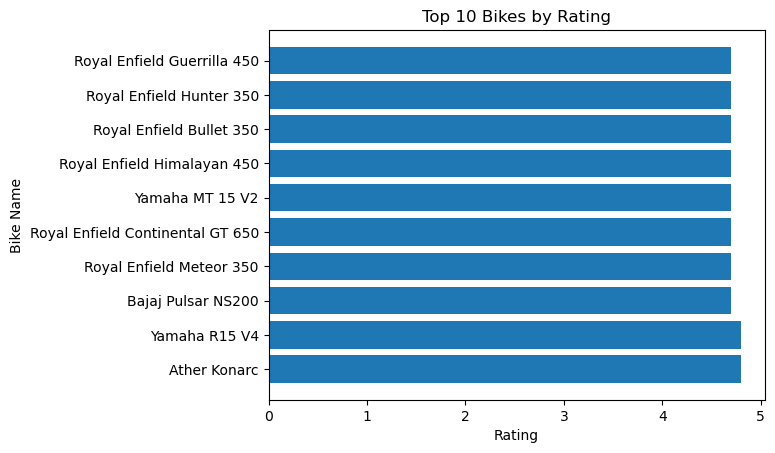

In [56]:
# Visualization 1 — Top 10 Bikes by  Rating

top_rating = df_clean.sort_values("Rating", ascending=False).head(10)

plt.barh(top_rating["Bike Name"], top_rating["Rating"])

plt.xlabel("Rating")
plt.ylabel("Bike Name")
plt.title("Top 10 Bikes by Rating")

plt.show()

**Observation:** The visualization shows that Yamaha R15 V4 and Ather Konarc have the highest rating of 4.8 in the scraped dataset. Royal Enfield Hunter 350, Royal Enfield Bullet 350 and Yamaha MT 15 V2 also have high ratings of 4.7. Overall, the selected bikes have ratings ranging from relatively high to moderate.

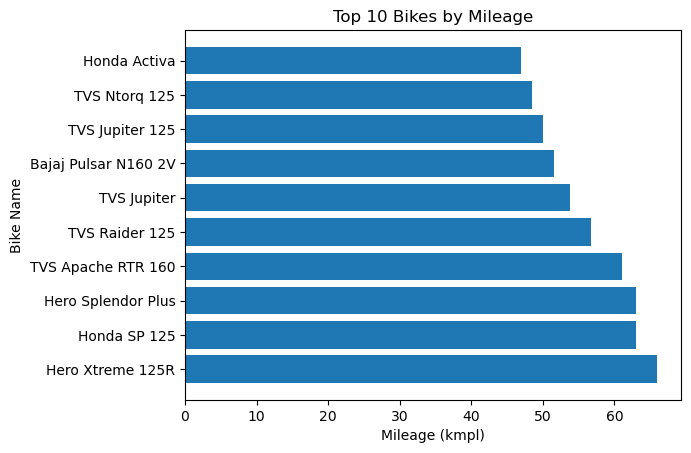

In [57]:
# Visualization 2 — Top 10 Bikes by Mileage

top_mileage = df_clean.dropna(
    subset=["Mileage (kmpl)"]
).sort_values(
    "Mileage (kmpl)",
    ascending=False
).head(10)

plt.barh(
    top_mileage["Bike Name"],
    top_mileage["Mileage (kmpl)"]
)

plt.xlabel("Mileage (kmpl)")
plt.ylabel("Bike Name")
plt.title("Top 10 Bikes by Mileage")

plt.show()

**Observation:** The visualization shows that Hero Xtreme 125R has the highest mileage of 66 kmpl, followed by Honda SP 125 and Hero Splendor Plus with 63 kmpl. Most of the top mileage bikes are commuter-oriented models, indicating a focus on fuel efficiency.

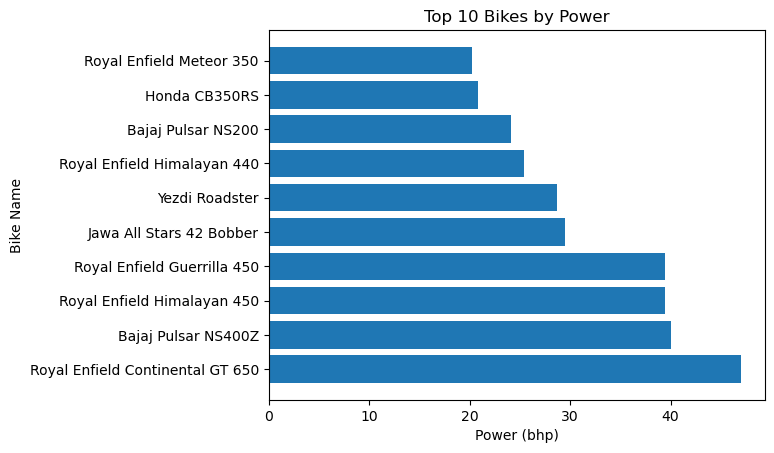

In [58]:
# Visualization 3 — Top 10 Bikes by Power

top_power = df_clean.dropna(
    subset=["Power (bhp)"]
).sort_values(
    "Power (bhp)",
    ascending=False
).head(10)

plt.barh(
    top_power["Bike Name"],
    top_power["Power (bhp)"]
)

plt.xlabel("Power (bhp)")
plt.ylabel("Bike Name")
plt.title("Top 10 Bikes by Power")

plt.show()

**Observation:** The visualization compares the power output of the top 10 bikes. Higher-power bikes are generally associated with larger engine capacities. Royal Enfield Continental GT 650 and Bajaj Pulsar NS400Z are among the high-power models in the dataset. This shows differences in performance across bike categories.

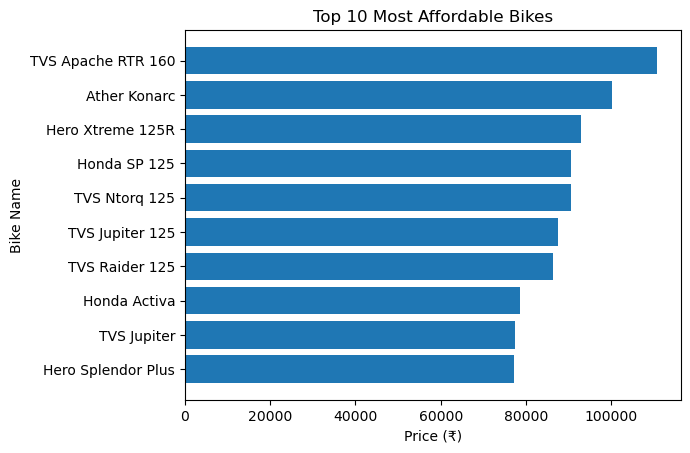

In [59]:
# Visualization 4 — Top 10 Most Affordable Bikes

top_affordable = df_clean.sort_values(
    "Price (₹)",
    ascending=True
).head(10)

plt.barh(
    top_affordable["Bike Name"],
    top_affordable["Price (₹)"]
)

plt.xlabel("Price (₹)")
plt.ylabel("Bike Name")
plt.title("Top 10 Most Affordable Bikes")

plt.show()

**Observation:** The visualization shows that Hero Splendor Plus is the most affordable bike at ₹77,124, followed by TVS Jupiter at ₹77,352 and Honda Activa at ₹78,687. The selected affordable bikes are mainly priced within the lower price range of the dataset.

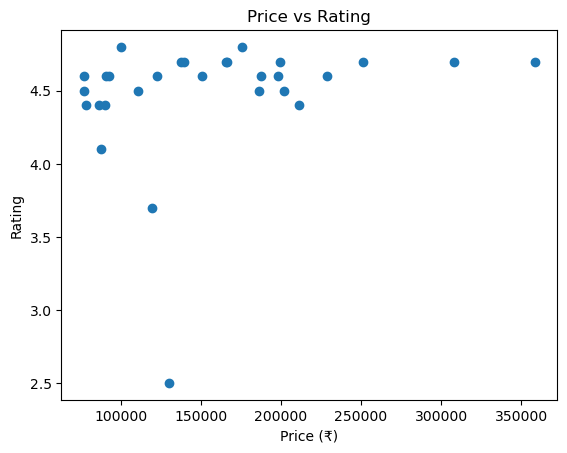

In [60]:
# Visualization 5 — Price vs Rating

plt.scatter(
    df_clean["Price (₹)"],
    df_clean["Rating"]
)

plt.xlabel("Price (₹)")
plt.ylabel("Rating")
plt.title("Price vs Rating")

plt.show()

**Observation:** The scatter plot shows that bikes across different price ranges can have similar ratings. This suggests that a higher price does not necessarily correspond to a higher customer rating in the scraped dataset. 

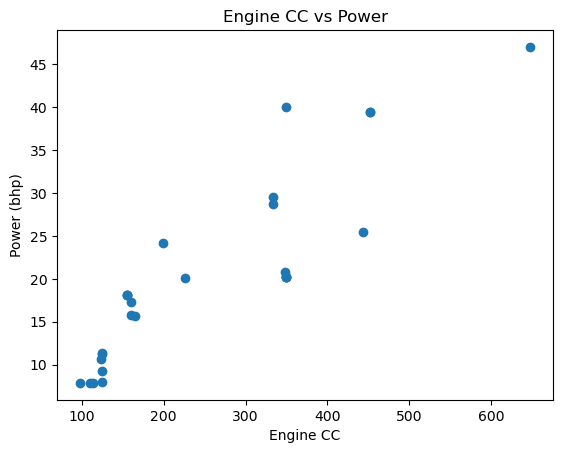

In [61]:
# Visualization 6 — Engine CC vs Power

engine_power = df_clean.dropna(
    subset=["Engine CC", "Power (bhp)"]
)

plt.scatter(
    engine_power["Engine CC"],
    engine_power["Power (bhp)"]
)

plt.xlabel("Engine CC")
plt.ylabel("Power (bhp)")
plt.title("Engine CC vs Power")

plt.show()

**Observation:** The scatter plot shows a generally positive relationship between engine capacity and power. Bikes with larger engine capacities tend to produce higher power, although the relationship is not perfectly proportional.

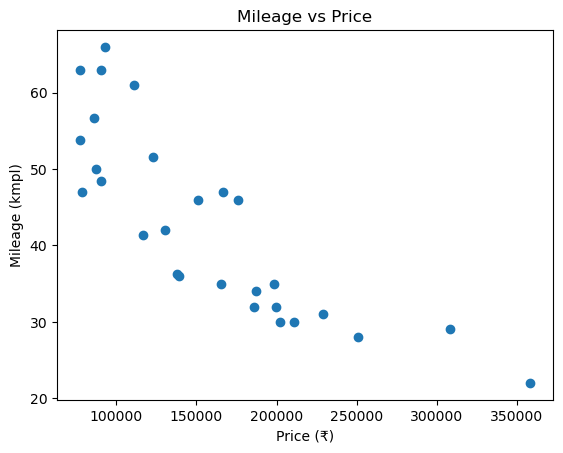

In [62]:
# Visualization 7 — Mileage vs Price

mileage_price = df_clean.dropna(
    subset=["Mileage (kmpl)", "Price (₹)"]
)

plt.scatter(
    mileage_price["Price (₹)"],
    mileage_price["Mileage (kmpl)"]
)

plt.xlabel("Price (₹)")
plt.ylabel("Mileage (kmpl)")
plt.title("Mileage vs Price")

plt.show()

**Observation:** The scatter plot shows a generally negative relationship between mileage and price. Several lower-priced bikes have higher mileage, while some higher-priced bikes have lower mileage. This indicates differences between commuter-oriented and performance-oriented models.

In [63]:
# Visualization 8 — Correlation Heatmap

import seaborn as sns

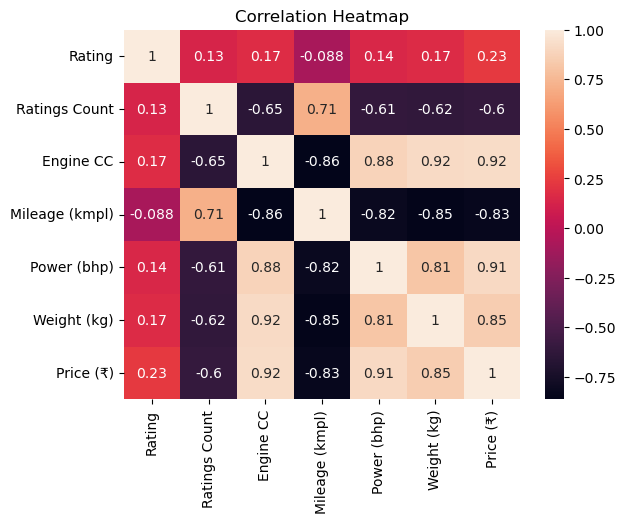

In [64]:
corr_columns = [
    "Rating",
    "Ratings Count",
    "Engine CC",
    "Mileage (kmpl)",
    "Power (bhp)",
    "Weight (kg)",
    "Price (₹)"
]

correlation_matrix = df_clean[corr_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

**Observation:** The correlation heatmap shows strong positive relationships between engine capacity, price, weight and power. Mileage has negative relationships with engine capacity, power and price. These relationships describe patterns in the dataset and do not establish cause and effect.

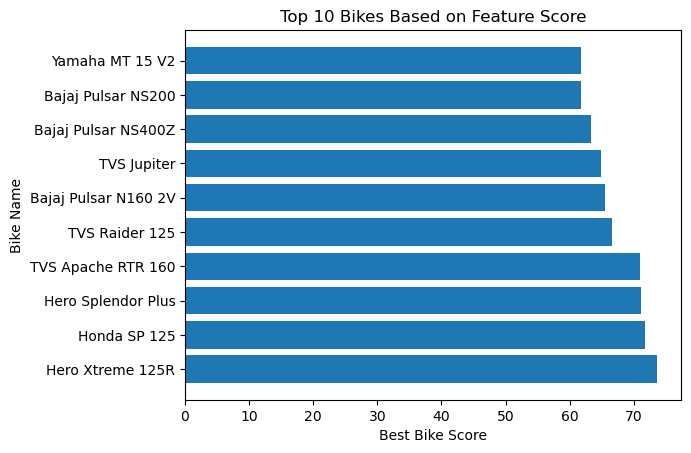

In [65]:
# Visualization 9 — Top 10 Feature-Based Best Bikes

top_best_bikes = best_bikes.head(10)

plt.barh(
    top_best_bikes["Bike Name"],
    top_best_bikes["Best Bike Score"]
)

plt.xlabel("Best Bike Score")
plt.ylabel("Bike Name")
plt.title("Top 10 Bikes Based on Feature Score")

plt.show()

**Observation:** The visualization compares the top 10 bikes using the project-defined Best Bike Score. The score combines rating, mileage, power and price after normalization. Higher scores indicate a stronger balance of these selected features according to the project's scoring method.

# PART 8 — BUSINESS INSIGHTS & RECOMMENDATIONS

### 8.1 Business Insights

**Mileage and Affordability:** Commuter-oriented bikes show competitive mileage and lower prices, making them relevant for customers who prioritize fuel efficiency and budget.
    
**Performance-Oriented Bikes:** Higher-capacity bikes generally provide greater power output, making them relevant for customers who prioritize performance.
    
**Customer Engagement:** Some bikes have a higher number of customer ratings, indicating greater customer engagement within the scraped dataset.
    
**Price and Rating:** Bikes across different price ranges can have similar customer ratings. Therefore, price alone may not indicate customer satisfaction.
    
**Feature-Based Comparison:** The project-defined Best Bike Score helps compare bikes using rating, mileage, power and price together.
    
**Different Customer Requirements:** Customers may prioritize different features, such as affordability, mileage, power or overall balance. Therefore, bike selection depends on individual preferences and requirements.

### 8.2 Business Recommendations

**Budget-Friendly Recommendations:** Customers who prioritize affordability and mileage can consider commuter bikes with lower prices and good fuel efficiency.
    
**Performance-Based Recommendations:** Customers who prioritize power and performance can explore bikes with higher engine capacity and power output.
    
**Feature-Based Comparison:** Customers should compare bikes using multiple features, including price, rating, mileage, power and weight, instead of relying on only one feature.
    
**Customer Preference Segmentation:** Bike manufacturers and sellers can categorize customers based on their preferences, such as affordability, fuel efficiency, performance and overall value.
    
**Data-Driven Decision Making:** The analysis can help customers and businesses make informed decisions by comparing different bike features in a structured way.
    
**Future Analysis:** The project can be improved by collecting data from more bike models and including additional features such as maintenance cost, fuel type and customer reviews.

## PART 9 — POWER BI DASHBOARD PLAN

### 9.1 Data Import

Import the generated `BikeWale_Cleaned_Dataset.csv` file into Power BI.

### 9.2 Dashboard Title

**BikeWale Bike Market Analysis Dashboard**

### 9.3 Key Performance Indicators (Cards)

* **Number of Bikes** — Count of bike names
* **Average Rating** — Average customer rating
* **Minimum Price** — Lowest bike price
* **Maximum Power** — Highest power output

### 9.4 Recommended Charts

1. **Top 10 Bikes by Rating** — Bar chart
2. **Top 10 Bikes by Mileage** — Bar chart
3. **Top 10 Bikes by Power** — Bar chart
4. **Price vs Rating** — Scatter chart
5. **Top 10 Feature-Based Best Bikes** — Bar chart

### 9.5 Dashboard Slicers

* Bike Name
* Rating
* Price

### 9.6 Dashboard Objective

The dashboard will provide an interactive view of bike ratings, mileage, power, prices and feature-based scores. It will help users compare bikes according to their preferences and understand the patterns in the scraped BikeWale dataset.


# PART 10 — FINAL CONCLUSION

The project demonstrates an end-to-end data pipeline:

**BikeWale → Requests → BeautifulSoup → Regex → Pandas → Data Cleaning → EDA → Visualization → Business Insights → Dashboard**

This project analyzed bike-related data collected from the BikeWale website using Python, BeautifulSoup and Regular Expressions. The extracted data was cleaned, structured and analyzed using Pandas.

Exploratory Data Analysis helped identify patterns in bike prices, ratings, mileage, engine capacity, power and weight. Visualizations were used to compare different bike features and understand relationships between numerical variables.

The project-defined Value Score and Best Bike Score provided additional ways to compare bikes based on multiple features. Overall, this project demonstrates an end-to-end data analytics workflow, from web scraping and data cleaning to exploratory analysis, visualization and business recommendations.

### Important limitations
- BikeWale is a live website, so values/listings can change.
- The scraped page represents a listing-page sample, not the entire BikeWale catalog.
- Some electric bikes have different specifications, so they may be excluded from conventional mileage/power comparisons.
- The combined score is a project-defined metric, not an official website ranking.

## Updated Data Dictionary and Export

In [66]:
# Create an updated data dictionary for all final dataset columns
data_dictionary = pd.DataFrame({
    "Column Name": df_clean.columns,
    "Description": [
        "Name of the bike",
        "Bike rating out of 5",
        "Number of user ratings",
        "Engine capacity in CC",
        "Mileage in kmpl",
        "Power in bhp",
        "Bike weight in kg",
        "Bike price in rupees",
        "Project-defined value score",
        "Project-defined popularity score",
        "Price divided by power in bhp"
    ]
})

display(data_dictionary)

# Save the updated files
df_clean.to_csv("BikeWale_Cleaned_Dataset.csv", index=False)
data_dictionary.to_csv("BikeWale_Data_Dictionary.csv", index=False)

print("Cleaned dataset and data dictionary saved successfully!")

,Column Name,Description
0,Bike Name,Name of the bike
1,Rating,Bike rating out of 5
2,Ratings Count,Number of user ratings
3,Engine CC,Engine capacity in CC
4,Mileage (kmpl),Mileage in kmpl
5,Power (bhp),Power in bhp
6,Weight (kg),Bike weight in kg
7,Price (₹),Bike price in rupees
8,Value Score,Project-defined value score
9,Popularity Score,Project-defined popularity score


Cleaned dataset and data dictionary saved successfully!
